In [5]:
from google.colab import files
uploaded = files.upload()


Saving validated_clean_train.csv to validated_clean_train.csv


In [6]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


**Load data & prepare features:**

---



In [7]:
df = pd.read_csv('validated_clean_train.csv')
print(f"Dataset shape: {df.shape}")

# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print(f"Features: {X.shape[1]}")
print(f"Target: {y.shape[0]} samples")
print(f"\nTarget Stats:")
print(y.describe())

Dataset shape: (1460, 79)
Features: 78
Target: 1460 samples

Target Stats:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


**Handle categorical columns & split data:**

---



In [8]:
# One-Hot Encode categorical columns
X = pd.get_dummies(X, drop_first=True)
print(f"Shape after encoding: {X.shape}")

# Train/Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Shape after encoding: (1460, 234)

Training set: (1168, 234)
Testing set:  (292, 234)


**Train all 3 models:**

---



In [9]:
# Define all 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        'RMSE': round(rmse, 2),
        'MAE':  round(mae, 2),
        'R2':   round(r2, 4)
    }

    print(f"\n{name}")
    print(f"  RMSE : ${rmse:,.2f}")
    print(f"  MAE  : ${mae:,.2f}")
    print(f"  R2   : {r2:.4f}")


Linear Regression
  RMSE : $36,313.04
  MAE  : $20,002.51
  R2   : 0.8281

Random Forest
  RMSE : $27,747.21
  MAE  : $16,956.22
  R2   : 0.8996

XGBoost
  RMSE : $26,770.17
  MAE  : $17,164.02
  R2   : 0.9066


**Compare results visually:**

---




Model Comparison:
                       RMSE       MAE      R2
Linear Regression  36313.04  20002.51  0.8281
Random Forest      27747.21  16956.22  0.8996
XGBoost            26770.17  17164.02  0.9066


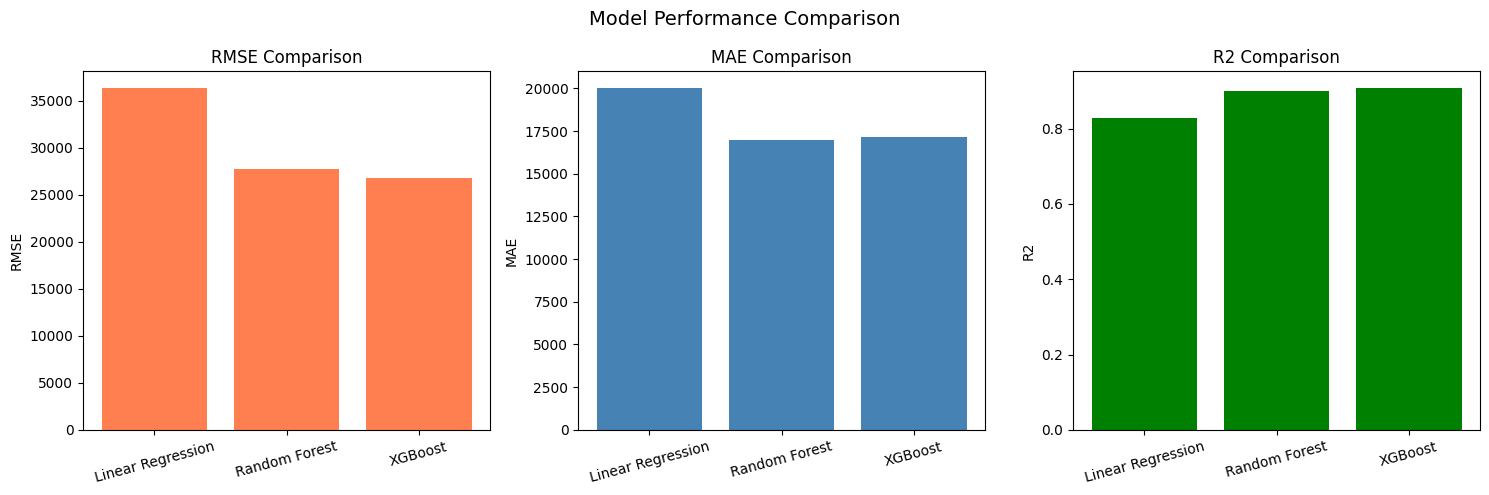


Results saved!


In [10]:
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['RMSE', 'MAE', 'R2']
colors  = ['coral', 'steelblue', 'green']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric], color=colors[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Save results
results_df.to_csv('model_comparison.csv')
print("\nResults saved!")

**Feature Importance (XGBoost):**

---



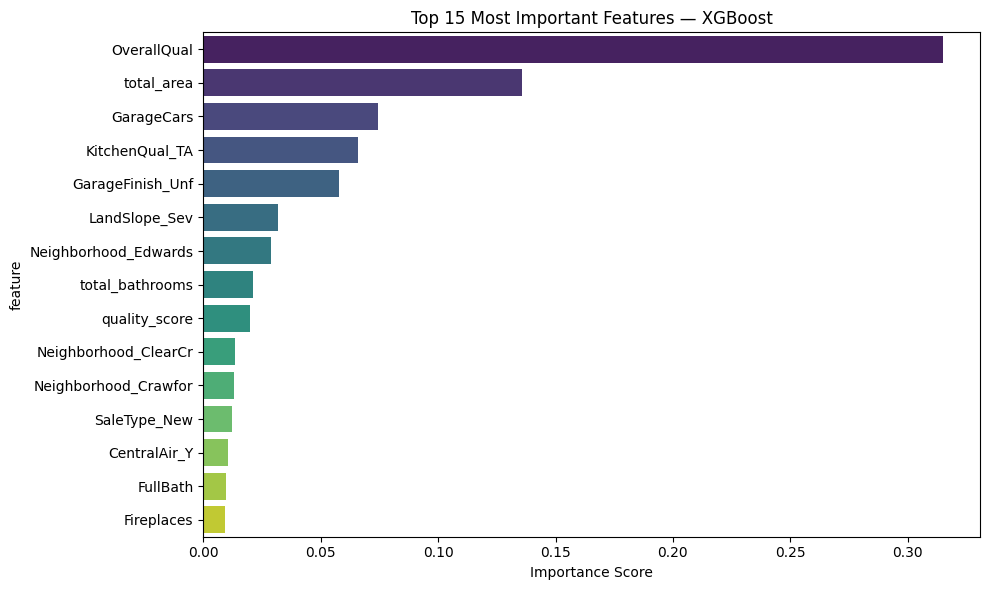

Top 5 features:
              feature  importance
4         OverallQual    0.315010
39         total_area    0.135681
26         GarageCars    0.074367
197    KitchenQual_TA    0.065762
210  GarageFinish_Unf    0.057959


In [11]:
# Get best model
best_model = models['XGBoost']

# Feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Top 15 Most Important Features — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importance_df.head())

**Save best model:**

---



In [12]:
import pickle

# Save XGBoost model
with open('best_model_xgboost.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved as best_model_xgboost.pkl")

# Download it
from google.colab import files
files.download('best_model_xgboost.pkl')
files.download('model_comparison.csv')

Model saved as best_model_xgboost.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>